In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [33]:
df = pd.read_csv(r"C:\Users\merve\Desktop\Calismalar\E-Com-Shipping-Dataset\shipping.csv")

In [34]:
df

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1
...,...,...,...,...,...,...,...,...,...,...,...,...
10994,10995,A,Ship,4,1,252,5,medium,F,1,1538,1
10995,10996,B,Ship,4,1,232,5,medium,F,6,1247,0
10996,10997,C,Ship,5,4,242,5,low,F,4,1155,0
10997,10998,F,Ship,5,2,223,6,medium,M,2,1210,0


In [35]:
#Warehouse_block : Şirketin blokları .A,B,C,D,E,F
#Mode_of_Shipment : Şirketin ürünleri ulaştırma şekli. 
#Customer_care_calls : Gönderi bilgisi için yapılan çağrı sayısı
#Customer_rating : Şirketin müsteriden aldığı puanlar.1'den 5'e
#Cost_of_the_Product : Ürün maliyeti(dolar)
#Prior_purchases : Önceki satın alma sayısı
#Product_importance : Şirketin ürüne verdiği kategori
#Discount_offered : Ürüne uygulanan indirim
#Weight_in_gms : Ürünün ağırlığı
#Reached.on.Time_Y.N : 1: ürün zamanında ulaşmadı , 0: ürün zamanında ulaştı

In [36]:
df.isnull().sum()

ID                     0
Warehouse_block        0
Mode_of_Shipment       0
Customer_care_calls    0
Customer_rating        0
Cost_of_the_Product    0
Prior_purchases        0
Product_importance     0
Gender                 0
Discount_offered       0
Weight_in_gms          0
Reached.on.Time_Y.N    0
dtype: int64

In [37]:
df.describe()

,ID,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
count,10999.00000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000
mean,5500.00000,4.054459,2.990545,210.196836,3.567597,13.373216,3634.016729,0.596691
std,3175.28214,1.141490,1.413603,48.063272,1.522860,16.205527,1635.377251,0.490584
min,1.00000,2.000000,1.000000,96.000000,2.000000,1.000000,1001.000000,0.000000
25%,2750.50000,3.000000,2.000000,169.000000,3.000000,4.000000,1839.500000,0.000000
50%,5500.00000,4.000000,3.000000,214.000000,3.000000,7.000000,4149.000000,1.000000
75%,8249.50000,5.000000,4.000000,251.000000,4.000000,10.000000,5050.000000,1.000000
max,10999.00000,7.000000,5.000000,310.000000,10.000000,65.000000,7846.000000,1.000000


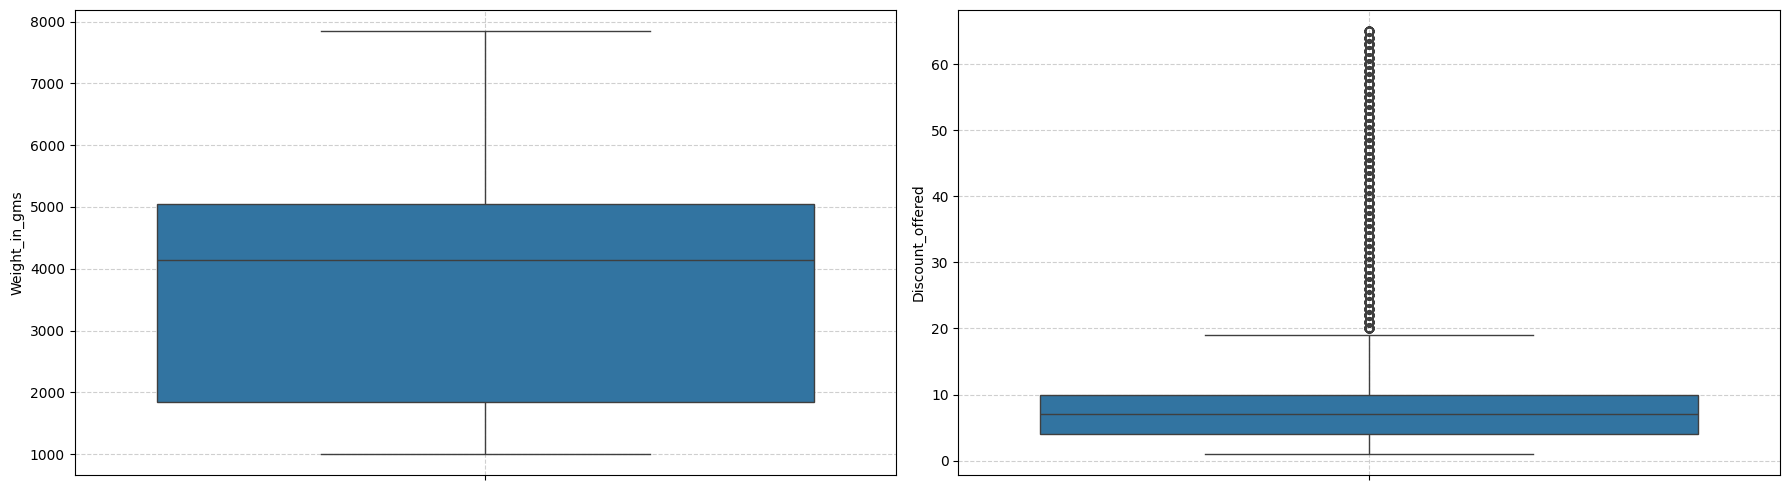

In [38]:
cols = ['Weight_in_gms','Discount_offered']
fig , axes =plt.subplots(1,2,figsize=(18,5))

for i , col in enumerate(cols):
    sns.boxplot(y=df[col] , ax= axes[i] )
    axes[i].set_ylabel(col)
    axes[i].grid(True , linestyle = '--' ,alpha=0.6 )
    
plt.tight_layout()
plt.show()

In [39]:
df = df.drop('ID',axis=1)

In [40]:
df['Warehouse_block'].value_counts()

Warehouse_block
F    3666
D    1834
A    1833
B    1833
C    1833
Name: count, dtype: int64

In [41]:
df['Mode_of_Shipment'].value_counts()

Mode_of_Shipment
Ship      7462
Flight    1777
Road      1760
Name: count, dtype: int64

In [42]:
df['Product_importance'].value_counts()

Product_importance
low       5297
medium    4754
high       948
Name: count, dtype: int64

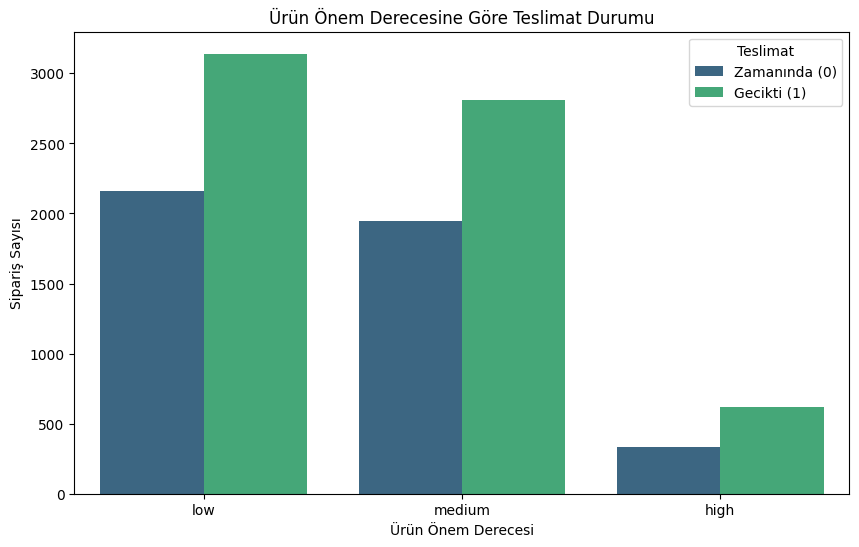

In [43]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Product_importance', hue='Reached.on.Time_Y.N', data=df, palette='viridis')
plt.title('Ürün Önem Derecesine Göre Teslimat Durumu')
plt.xlabel('Ürün Önem Derecesi')
plt.ylabel('Sipariş Sayısı')
plt.legend(title='Teslimat', labels=['Zamanında (0)', 'Gecikti (1)'])
plt.show()

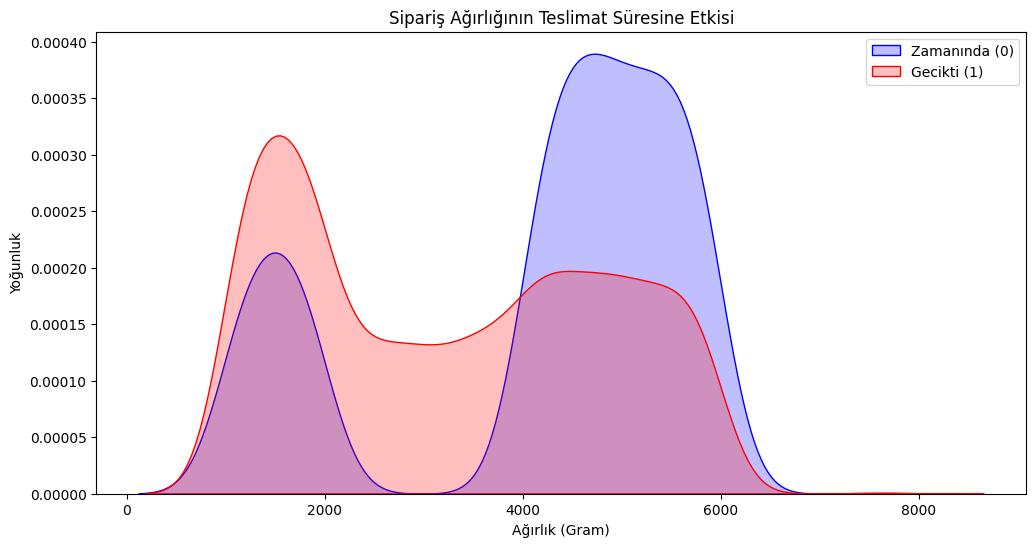

In [44]:
plt.figure(figsize=(12, 6))
sns.kdeplot(data=df[df['Reached.on.Time_Y.N'] == 0]['Weight_in_gms'], label='Zamanında (0)', fill=True, color='blue')
sns.kdeplot(data=df[df['Reached.on.Time_Y.N'] == 1]['Weight_in_gms'], label='Gecikti (1)', fill=True, color='red')
plt.title('Sipariş Ağırlığının Teslimat Süresine Etkisi')
plt.xlabel('Ağırlık (Gram)')
plt.ylabel('Yoğunluk')
plt.legend()
plt.show()

In [45]:
X=df.drop('Reached.on.Time_Y.N', axis=1)
y=df['Reached.on.Time_Y.N']

In [46]:
from sklearn.model_selection import train_test_split
X_train ,X_test , y_train,y_test = train_test_split(X,y,test_size=0.2, random_state=42)

In [47]:
df

,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,D,Flight,4,2,177,3,low,F,44,1233,1
1,F,Flight,4,5,216,2,low,M,59,3088,1
2,A,Flight,2,2,183,4,low,M,48,3374,1
3,B,Flight,3,3,176,4,medium,M,10,1177,1
4,C,Flight,2,2,184,3,medium,F,46,2484,1
...,...,...,...,...,...,...,...,...,...,...,...
10994,A,Ship,4,1,252,5,medium,F,1,1538,1
10995,B,Ship,4,1,232,5,medium,F,6,1247,0
10996,C,Ship,5,4,242,5,low,F,4,1155,0
10997,F,Ship,5,2,223,6,medium,M,2,1210,0


In [48]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.pipeline import Pipeline

onehot =['Warehouse_block','Mode_of_Shipment','Gender']
ord = ['Product_importance']
scaler = ['Customer_care_calls', 'Customer_rating','Cost_of_the_Product' , 'Prior_purchases','Discount_offered','Weight_in_gms' ]

prep = ColumnTransformer(
    transformers=[
        ('onehot',OneHotEncoder(drop='first',handle_unknown='ignore'),onehot),
        ('ordinal',OrdinalEncoder(categories=[['low','medium','high']]) ,ord),
        ('scaler',StandardScaler(),scaler)
    ] , remainder='passthrough'
)

X_train_prep = prep.fit_transform(X_train)
X_test_prep = prep.transform(X_test)


In [49]:
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [50]:
adaboost = AdaBoostClassifier(n_estimators=100, random_state=42)

pipeline = Pipeline(steps=[
    ('preprocessor' , prep),
    ('adaboost', adaboost)
])

pipeline.fit(X_train,y_train)
y_pred_ada=pipeline.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report

print('accuracy : ' , accuracy_score(y_pred_ada,y_test))
print('classification report : \n ' , classification_report(y_pred_ada,y_test))

accuracy :  0.6813636363636364
classification report : 
                precision    recall  f1-score   support

           0       0.74      0.59      0.65      1128
           1       0.64      0.78      0.71      1072

    accuracy                           0.68      2200
   macro avg       0.69      0.68      0.68      2200
weighted avg       0.69      0.68      0.68      2200



In [51]:
xgb=XGBClassifier()

pipeline = Pipeline(steps=[
    ('preprocessor' , prep),
    ('xgb', xgb)
])

pipeline.fit(X_train,y_train)
y_pred_xgb=pipeline.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report

print('accuracy : ' , accuracy_score(y_pred_xgb,y_test))
print('classification report : \n ' , classification_report(y_pred_xgb,y_test))

accuracy :  0.6572727272727272
classification report : 
                precision    recall  f1-score   support

           0       0.62      0.57      0.60       977
           1       0.68      0.73      0.70      1223

    accuracy                           0.66      2200
   macro avg       0.65      0.65      0.65      2200
weighted avg       0.66      0.66      0.66      2200



In [52]:
lgbm=LGBMClassifier()

pipeline = Pipeline(steps=[
    ('preprocessor' , prep),
    ('lgbm', lgbm)
])

pipeline.fit(X_train,y_train)
y_pred_lgbm=pipeline.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report

print('accuracy : ' , accuracy_score(y_pred_lgbm,y_test))
print('classification report : \n ' , classification_report(y_pred_lgbm,y_test))

[LightGBM] [Info] Number of positive: 5258, number of negative: 3541
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000131 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 575
[LightGBM] [Info] Number of data points in the train set: 8799, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.597568 -> initscore=0.395342
[LightGBM] [Info] Start training from score 0.395342
accuracy :  0.6663636363636364
classification report : 
                precision    recall  f1-score   support

           0       0.74      0.57      0.64      1157
           1       0.62      0.77      0.69      1043

    accuracy                           0.67      2200
   macro avg       0.68      0.67      0.66      2200
weighted avg       0.68      0.67      0.66      2200



c:\Users\merve\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [53]:
gradient = GradientBoostingClassifier()

pipeline = Pipeline(steps=[
    ('preprocessor' , prep),
    ('gradient', gradient)
])

pipeline.fit(X_train,y_train)
y_pred_grad=pipeline.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report

print('accuracy : ' , accuracy_score(y_pred_grad,y_test))
print('classification report : \n ' , classification_report(y_pred_grad,y_test))

accuracy :  0.6845454545454546
classification report : 
                precision    recall  f1-score   support

           0       0.87      0.57      0.69      1359
           1       0.56      0.86      0.68       841

    accuracy                           0.68      2200
   macro avg       0.71      0.72      0.68      2200
weighted avg       0.75      0.68      0.69      2200



In [54]:
from sklearn.model_selection import GridSearchCV

param_grid={
    'gradient__n_estimators' : [100,200,300],
    'gradient__learning_rate' :[0.01,0.1,1.0],
    'gradient__max_depth' : [3,4,5],
    'gradient__min_samples_split' : [2,5,10]
}

grid_search=GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    scoring='accuracy',
    verbose=2
)

grid_search.fit(X_train,y_train)

print("En İyi Parametreler:\n", grid_search.best_params_)
print("\nEğitim Setindeki En İyi Skor (Cross-Validation Accuracy):", grid_search.best_score_)

best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_best))
print("\nClassification Report:\n", classification_report(y_test, y_pred_best))

Fitting 5 folds for each of 81 candidates, totalling 405 fits
En İyi Parametreler:
 {'gradient__learning_rate': 0.01, 'gradient__max_depth': 3, 'gradient__min_samples_split': 2, 'gradient__n_estimators': 200}

Eğitim Setindeki En İyi Skor (Cross-Validation Accuracy): 0.6845112150498736
Accuracy: 0.6904545454545454

Classification Report:
               precision    recall  f1-score   support

           0       0.57      0.95      0.71       895
           1       0.93      0.52      0.66      1305

    accuracy                           0.69      2200
   macro avg       0.75      0.73      0.69      2200
weighted avg       0.79      0.69      0.68      2200



In [55]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

log = LogisticRegression()

pipeline = Pipeline(steps=[
    ('preprocessor' , prep),
    ('log', log)
])

pipeline.fit(X_train,y_train)
y_pred_log=pipeline.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report

print('accuracy : ' , accuracy_score(y_pred_log,y_test))
print('classification report : \n ' , classification_report(y_pred_log,y_test))

accuracy :  0.6427272727272727
classification report : 
                precision    recall  f1-score   support

           0       0.56      0.56      0.56       901
           1       0.70      0.70      0.70      1299

    accuracy                           0.64      2200
   macro avg       0.63      0.63      0.63      2200
weighted avg       0.64      0.64      0.64      2200



In [56]:
kn = KNeighborsClassifier()

pipeline = Pipeline(steps=[
    ('preprocessor' , prep),
    ('kn', kn)
])

pipeline.fit(X_train,y_train)
y_pred_kn=pipeline.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report

print('accuracy : ' , accuracy_score(y_pred_kn,y_test))
print('classification report : \n ' , classification_report(y_pred_kn,y_test))

accuracy :  0.6377272727272727
classification report : 
                precision    recall  f1-score   support

           0       0.61      0.55      0.58       986
           1       0.66      0.71      0.68      1214

    accuracy                           0.64      2200
   macro avg       0.63      0.63      0.63      2200
weighted avg       0.64      0.64      0.64      2200



In [57]:
dec = DecisionTreeClassifier()

pipeline = Pipeline(steps=[
    ('preprocessor' , prep),
    ('decision_tree', dec       )
])

pipeline.fit(X_train,y_train)
y_pred_dec=pipeline.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report

print('accuracy : ' , accuracy_score(y_pred_dec,y_test))
print('classification report : \n ' , classification_report(y_pred_dec,y_test))

accuracy :  0.6436363636363637
classification report : 
                precision    recall  f1-score   support

           0       0.56      0.56      0.56       889
           1       0.70      0.70      0.70      1311

    accuracy                           0.64      2200
   macro avg       0.63      0.63      0.63      2200
weighted avg       0.64      0.64      0.64      2200



In [58]:
random = RandomForestClassifier()

pipeline = Pipeline(steps=[
    ('preprocessor' , prep),
    ('random', random)
])

pipeline.fit(X_train,y_train)
y_pred_random=pipeline.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report

print('accuracy : ' , accuracy_score(y_pred_random,y_test))
print('classification report : \n ' , classification_report(y_pred_random,y_test))

accuracy :  0.6613636363636364
classification report : 
                precision    recall  f1-score   support

           0       0.70      0.57      0.63      1096
           1       0.64      0.75      0.69      1104

    accuracy                           0.66      2200
   macro avg       0.67      0.66      0.66      2200
weighted avg       0.67      0.66      0.66      2200



In [59]:
param_grid_rf = {
    'random__n_estimators': [100, 200, 300],          
    'random__max_depth': [5, 10, 15, None],    
    'random__min_samples_split': [2, 5, 10],          
    'random__class_weight': ['balanced', None]    
}

grid_search_rf = GridSearchCV(
    estimator=pipeline, 
    param_grid=param_grid_rf, 
    cv=5, 
    scoring='accuracy', 
    n_jobs=-1, 
    verbose=2
)
grid_search_rf.fit(X_train, y_train)

print("En İyi Parametreler:\n", grid_search_rf.best_params_)
print("\nEğitim Setindeki En İyi Skor (CV Accuracy):", grid_search_rf.best_score_)

best_rf_model = grid_search_rf.best_estimator_
y_pred_rf = best_rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

Fitting 5 folds for each of 72 candidates, totalling 360 fits
En İyi Parametreler:
 {'random__class_weight': 'balanced', 'random__max_depth': 5, 'random__min_samples_split': 2, 'random__n_estimators': 300}

Eğitim Setindeki En İyi Skor (CV Accuracy): 0.6855338131169569
Accuracy: 0.69

Classification Report:
               precision    recall  f1-score   support

           0       0.57      0.98      0.72       895
           1       0.97      0.49      0.65      1305

    accuracy                           0.69      2200
   macro avg       0.77      0.73      0.69      2200
weighted avg       0.81      0.69      0.68      2200



In [60]:
import pickle 

with open ('e_shipping_complete.pkl' , 'wb') as f :
    pickle.dump({
        'model' : best_rf_model
    } , f  )

In [61]:
X_test.to_csv(r"C:\Users\merve\Desktop\Calismalar\E-Com-Shipping-Dataset\e_shipping_best.csv", index=False)